# LAB 3: Regression & Classification

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, 
    precision_score, recall_score, f1_score, 
    confusion_matrix, roc_curve, auc
)

# 0. Load Data
df = pd.read_csv('Microsoft_stock_history.csv')
print("ข้อมูลพร้อม")

# Preprocessing เบื้องต้น
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna().drop_duplicates()

ข้อมูลพร้อม


# LAB 1: Regression (การทำนายราคาปิด - Close Price)

In [17]:
print("=== LAB 1: Regression ===")

# --- 1.1 Simple Linear Regression (ใช้ 1 ตัวแปร Open) ---
X_simple = df[['Open']]
y_reg = df['Close']

X_train_s, X_test_s, y_train_r, y_test_r = train_test_split(
    X_simple, y_reg, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_r)
y_pred_s = model_simple.predict(X_test_s)

# --- 1.2 Multiple Linear Regression + PCA (ใช้หลายตัวแปร) ---
features = ['Open', 'High', 'Low', 'Volume']
X_multi = df[features]

# Standardize ก่อนทำ PCA
scaler_r = StandardScaler()
X_scaled_r = scaler_r.fit_transform(X_multi)

# ใช้ PCA ลดมิติข้อมูลเหลือ 2 Components
pca_r = PCA(n_components=2)
X_pca_r = pca_r.fit_transform(X_scaled_r)

X_train_m, X_test_m, y_train_rm, y_test_rm = train_test_split(
    X_pca_r, y_reg, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_rm)
y_pred_m = model_multi.predict(X_test_m)

# --- 1.3 Stock Price Prediction Evaluation ---
mse_s = mean_squared_error(y_test_r, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_r, y_pred_s)

mse_m = mean_squared_error(y_test_rm, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_rm, y_pred_m)

print(f"Simple Linear Regression -> RMSE: {rmse_s:.4f}, R2: {r2_s:.4f}")
print(f"Multiple Linear Regression (PCA) -> RMSE: {rmse_m:.4f}, R2: {r2_m:.4f}")

=== LAB 1: Regression ===
Simple Linear Regression -> RMSE: 1.7012, R2: 0.9998
Multiple Linear Regression (PCA) -> RMSE: 1.1571, R2: 0.9999


# LAB 2: Classification (ทำนายทิศทางราคาขึ้น/ลง)


=== LAB 2: Classification ===


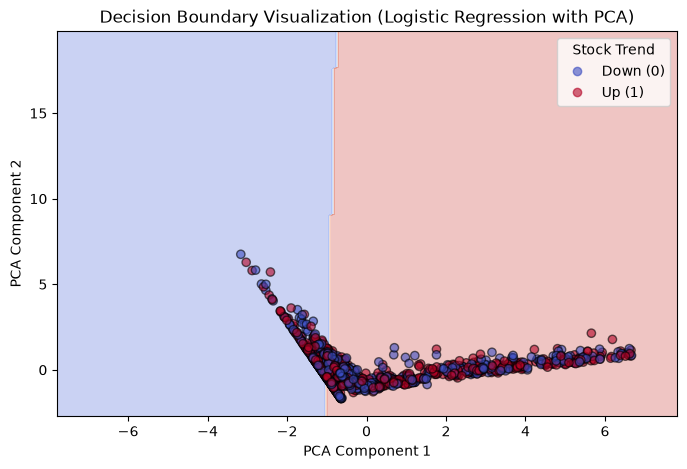

Confusion Matrix:
 [[202 801]
 [223 794]]
Accuracy: 0.4931, Precision: 0.4978, Recall: 0.7807, F1-Score: 0.6080


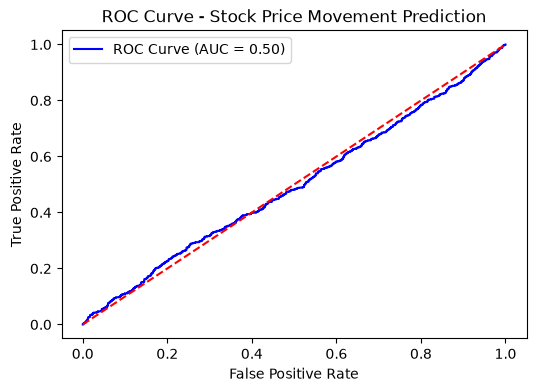

In [18]:
print("\n=== LAB 2: Classification ===")

# --- 2.1 Preparing Classification Data ---
# สร้าง Target: ถ้าราคาปิดวันนี้ > วันก่อน ให้เป็น 1 (ขึ้น) ถ้าไม่ให้เป็น 0 (ลง)
df['Price_Diff'] = df['Close'].diff()
df['Target'] = (df['Price_Diff'] > 0).astype(int)
df_cls = df.dropna().copy()

X_cls = df_cls[['Open', 'High', 'Low', 'Volume']]
y_cls = df_cls['Target']

scaler_c = StandardScaler()
X_cls_scaled = scaler_c.fit_transform(X_cls)

# ใช้ PCA ลดเหลือ 2 มิติเพื่อทำ Decision Boundary Visualization
pca_c = PCA(n_components=2)
X_cls_pca = pca_c.fit_transform(X_cls_scaled)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls_pca, y_cls, test_size=0.2, random_state=42
)

# --- 2.3 Logistic Regression ---
model_cls = LogisticRegression()
model_cls.fit(X_train_c, y_train_c)
y_pred_c = model_cls.predict(X_test_c)
y_prob_c = model_cls.predict_proba(X_test_c)[:, 1]

# --- 2.2 Decision Boundary Visualization ---
plt.figure(figsize=(8, 5))
x_min, x_max = X_cls_pca[:, 0].min() - 1, X_cls_pca[:, 0].max() + 1
y_min, y_max = X_cls_pca[:, 1].min() - 1, X_cls_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model_cls.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_test_c[:, 0], X_test_c[:, 1], c=y_test_c, cmap='coolwarm', edgecolors='k', alpha=0.6)
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Down (0)', 'Up (1)'], loc='upper right', title='Stock Trend')
plt.title('Decision Boundary Visualization (Logistic Regression with PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# --- 2.5 Confusion Matrix & Metrics ---
cm = confusion_matrix(y_test_c, y_pred_c)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}")

# ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test_c, y_prob_c)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stock Price Movement Prediction')
plt.legend()
plt.show()


# LAB 3: Model Comparison

In [19]:
print("\n=== LAB 3: Model Comparison ===")

# --- 3.1 Simple vs Multiple Linear Regression ---
print(f"1. Simple vs Multiple Linear Regression:")
print(f"   - Simple Regression R2: {r2_s:.4f}")
print(f"   - Multiple Regression (PCA) R2: {r2_m:.4f}")

# --- 3.2 Training vs Testing Performance ---
train_pred_s = model_simple.predict(X_train_s)
train_r2 = r2_score(y_train_r, train_pred_s)
print(f"2. Training vs Testing Performance (Simple Linear Regression):")
print(f"   - Training R2 Score: {train_r2:.4f}")
print(f"   - Testing R2 Score: {r2_s:.4f}")

# --- 3.3 Regression vs Classification สรุปผล ---
print("\n3. Regression vs Classification Summary:")
print("   - Regression ใช้ทำนายค่าตัวเลขต่อเนื่อง (ราคาปิดของหุ้น)")
print("   - Classification ใช้จำแนกหมวดหมู่/ทิศทาง (หุ้นขึ้น หรือ หุ้นลง)")

# --- 3.4 Model Performance Metrics สรุปตัววัดผล ---
summary_data = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression (PCA)', 'Logistic Regression'],
    'Task': ['Regression', 'Regression', 'Classification'],
    'Primary Metric 1': [f'RMSE: {rmse_s:.2f}', f'RMSE: {rmse_m:.2f}', f'Accuracy: {acc:.2f}'],
    'Primary Metric 2': [f'R2: {r2_s:.4f}', f'R2: {r2_m:.4f}', f'F1-Score: {f1:.2f}']
}
df_summary = pd.DataFrame(summary_data)
print("\n=== Summary Table ===")
print(df_summary.to_string(index=False))


=== LAB 3: Model Comparison ===
1. Simple vs Multiple Linear Regression:
   - Simple Regression R2: 0.9998
   - Multiple Regression (PCA) R2: 0.9999
2. Training vs Testing Performance (Simple Linear Regression):
   - Training R2 Score: 0.9998
   - Testing R2 Score: 0.9998

3. Regression vs Classification Summary:
   - Regression ใช้ทำนายค่าตัวเลขต่อเนื่อง (ราคาปิดของหุ้น)
   - Classification ใช้จำแนกหมวดหมู่/ทิศทาง (หุ้นขึ้น หรือ หุ้นลง)

=== Summary Table ===
                           Model           Task Primary Metric 1 Primary Metric 2
        Simple Linear Regression     Regression       RMSE: 1.70       R2: 0.9998
Multiple Linear Regression (PCA)     Regression       RMSE: 1.16       R2: 0.9999
             Logistic Regression Classification   Accuracy: 0.49   F1-Score: 0.61
